<h1>Predicting Banknote Authenticity Using Machine Learning</h1>

<p>
This notebook looks into using various Python-based machine learning and data science libraries 
in an attempt to build a machine learning model capable of predicting whether or not a banknote 
is authentic based on its statistical image attributes.
</p>

<p>We’re going to take the following steps:</p>

<ul>
    <li>Problem Definition</li>
    <li>Data</li>
    <li>Evaluation Metrics</li>
    <li>Features</li>
    <li>Modelling</li>
    <li>Experimentation</li>
</ul>

<h2>1. Problem Definition</h2>

<p><em>In a statement,</em></p>

<blockquote>
Given statistical parameters extracted from a banknote image, can we predict whether or not the note is authentic?
</blockquote>

<h2>2. Data</h2>

<p>
The original data came from the Banknote Authentication dataset from the 
<strong>UCI Machine Learning Repository</strong>.
</p>

<h2>3. Evaluation</h2>

<p>
If we can reach 95% accuracy at predicting whether or not a banknote is authentic 
during the proof of concept, we’ll pursue the project.
</p>

<h2>4. Features</h2>

<p>
This is where you'll get different information about each of the features in your data.
</p>

<h3>Create a Data Dictionary</h3>

<ul>
    <li><strong>variance</strong> (Variance of the wavelet-transformed image)</li>
    <li><strong>skewness</strong> (Skewness of the wavelet-transformed image)</li>
    <li><strong>kurtosis</strong> (Kurtosis of the wavelet-transformed image)</li>
    <li><strong>entropy</strong> (Entropy of the image)</li>
    <li><strong>class</strong> (The predicted attribute: 0 = Authentic, 1 = Forged)</li>
</ul>

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [9]:
headers = ['variance','skewness','curtosis','entropy','class']
df = pd.read_csv(r"D:\Machine Learning Projects\Fake notes detection\data_banknote_authentication.txt", names=headers)
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [10]:
df.rename(columns={'curtosis':'kurtosis'}, inplace =True);

In [11]:
df.describe()

,variance,skewness,kurtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   kurtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


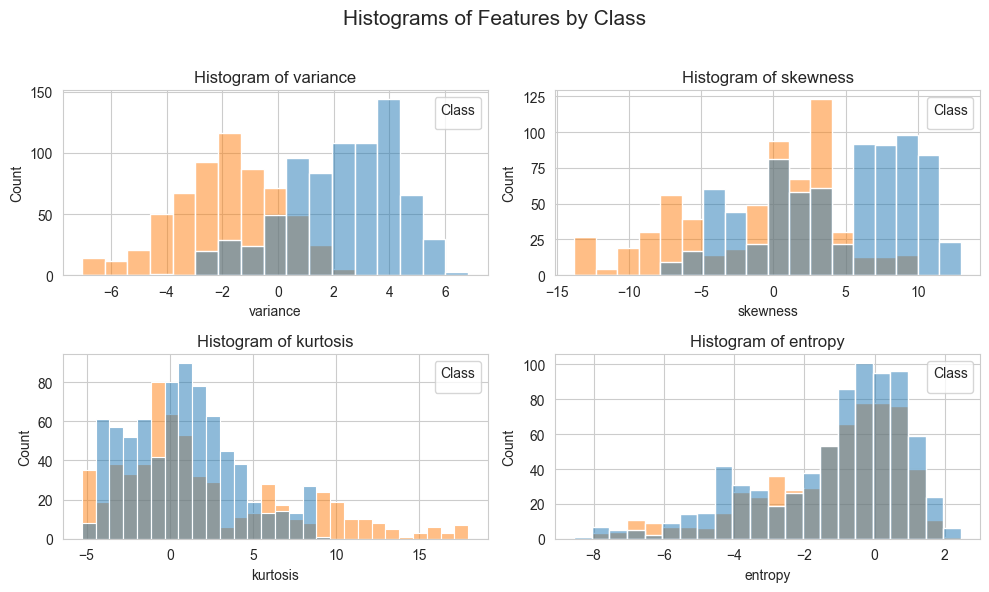

In [14]:

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Histograms of Features by Class", fontsize=15)
axes = axes.flatten()

features = ['variance', 'skewness', 'kurtosis', 'entropy']
for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, hue="class", ax=axes[i], kde=False)
    axes[i].set_title(f"Histogram of {feature}")
    axes[i].legend(title="Class")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

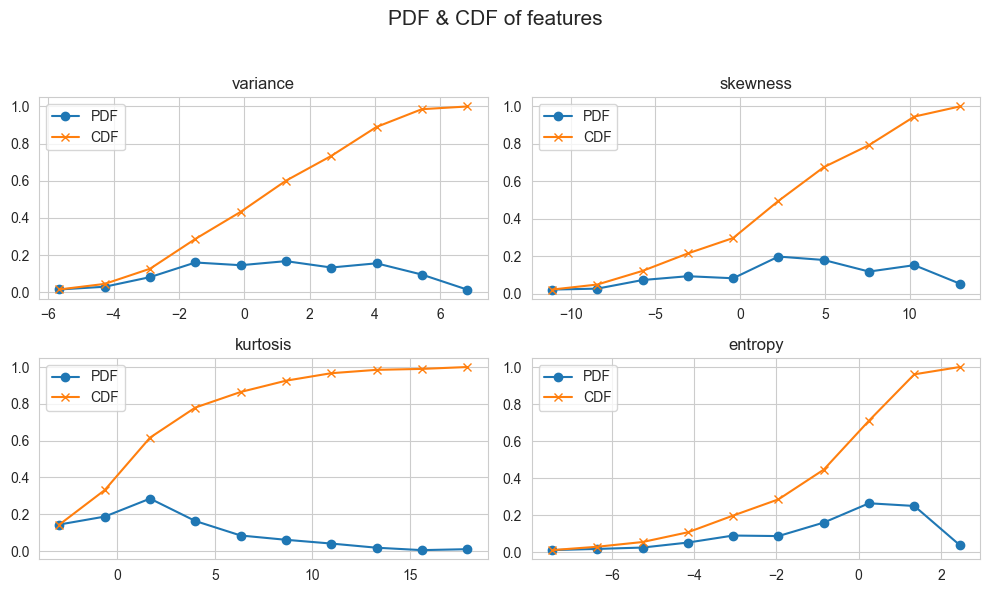

In [15]:
#PDF and CDF
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("PDF & CDF of features", fontsize=15)
axes = axes.flatten()
Features = ['variance', 'skewness', 'kurtosis', 'entropy']
for i, feature in enumerate(Features):
    data = df[feature]

    counts, bin_edges = np.histogram(data, bins=10, density=True)
    pdf = counts / sum(counts)
    cdf = np.cumsum(pdf)

    axes[i].plot(bin_edges[1:], pdf, label='PDF', marker='o')
    axes[i].plot(bin_edges[1:], cdf, label='CDF', marker='x')
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


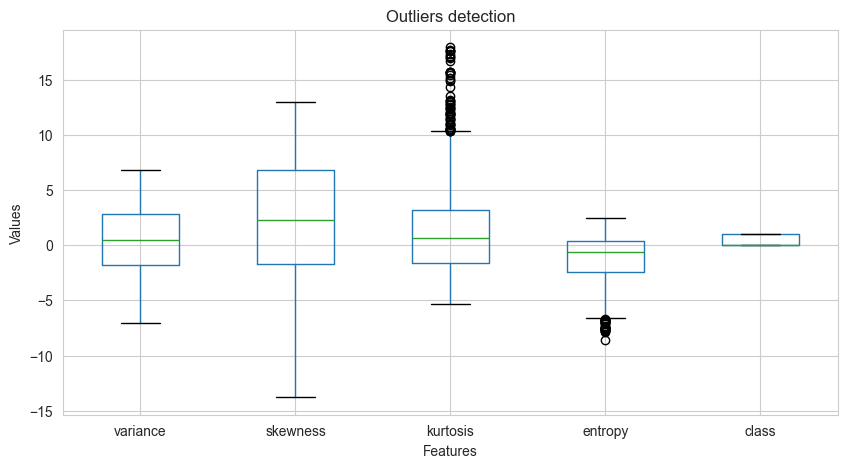

In [16]:
ax = df.boxplot(figsize=(10,5))
ax.set_xlabel('Features')
ax.set_ylabel('Values')
ax.set_title('Outliers detection')
plt.show()



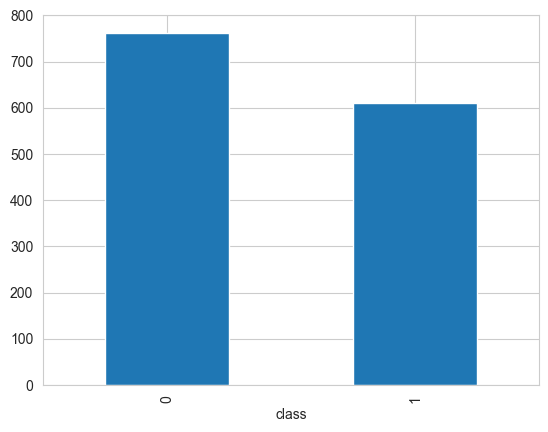

In [17]:
df['class'].value_counts().plot(kind= 'bar');

In [18]:
df['class'].value_counts()

class
0    762
1    610
Name: count, dtype: int64

In [19]:
X = df.iloc[:,:4].values
y = df.iloc[:,4].values

In [20]:
# split and scale

X_train,X_test,y_train,y_test =train_test_split(X, y, test_size = 0.3, random_state = 0)

sp = StandardScaler()
X_train_s = sp.fit_transform(X_train)
X_test_s = sp.transform(X_test)



In [21]:
#fitting knn

neigh = KNeighborsClassifier(n_neighbors=5, metric= 'minkowski', p=2)
neigh.fit(X_train_s,y_train)
y_pred=neigh.predict(X_test_s)

results = pd.DataFrame({'Predicted': y_pred, 'Actual': y_test})
print(results)


     Predicted  Actual
0            1       1
1            0       0
2            1       1
3            0       0
4            0       0
..         ...     ...
407          1       1
408          0       0
409          1       1
410          1       1
411          0       0

[412 rows x 2 columns]


the accuracy of the model is: 0.9976
The confusion matrix is:
[[231   1]
 [  0 180]]
---------------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       232
           1       0.99      1.00      1.00       180

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



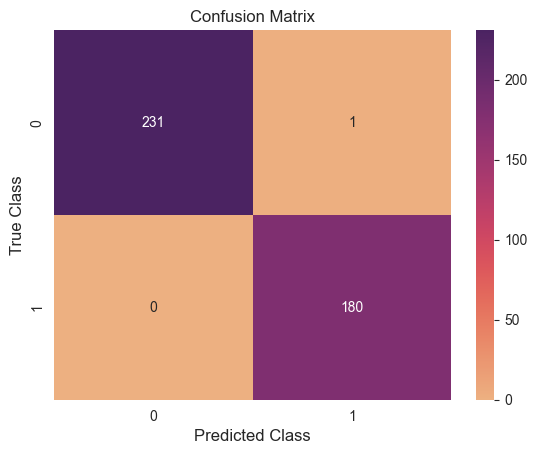

In [22]:
#performance
from sklearn import metrics
acc = metrics.accuracy_score(y_test,y_pred)
print(f"the accuracy of the model is: {acc:.4f}")

cm = metrics.confusion_matrix(y_test, y_pred)
print("The confusion matrix is:")
print(cm)
print('---------------------------------------')
result=metrics.classification_report(y_test, y_pred)
print('Classification Report:\n')
print(result)


ax = sns.heatmap(cm, cmap='flare',annot=True, fmt='d')
plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("True Class",fontsize=12)
plt.title("Confusion Matrix",fontsize=12)
plt.show()